In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Load and explore the data
df = pd.read_csv('kc_house_data.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (21613, 21)

First 5 rows:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())
print("\nBasic statistics:")
df.describe()



Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Duplicates:
0

Basic statistics:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [15]:
df.dtypes

,0
id,int64
date,object
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64


In [11]:
print("\nUnique values per column:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"Column '{col}': {unique_count} unique values")
    if unique_count <= 10 and col not in ['id']:
        print(f"  Unique values: {df[col].unique()}")


Unique values per column:
Column 'id': 21436 unique values
Column 'date': 372 unique values
Column 'price': 4028 unique values
Column 'bedrooms': 13 unique values
Column 'bathrooms': 30 unique values
Column 'sqft_living': 1038 unique values
Column 'sqft_lot': 9782 unique values
Column 'floors': 6 unique values
  Unique values: [1.  2.  1.5 3.  2.5 3.5]
Column 'waterfront': 2 unique values
  Unique values: [0 1]
Column 'view': 5 unique values
  Unique values: [0 3 4 2 1]
Column 'condition': 5 unique values
  Unique values: [3 5 4 1 2]
Column 'grade': 12 unique values
Column 'sqft_above': 946 unique values
Column 'sqft_basement': 306 unique values
Column 'yr_built': 116 unique values
Column 'yr_renovated': 70 unique values
Column 'zipcode': 70 unique values
Column 'lat': 5034 unique values
Column 'long': 752 unique values
Column 'sqft_living15': 777 unique values
Column 'sqft_lot15': 8689 unique values


In [13]:
print("\nChecking for outliers:")
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

id: 0 outliers (0.00%)
price: 1146 outliers (5.30%)
bedrooms: 546 outliers (2.53%)
bathrooms: 571 outliers (2.64%)
sqft_living: 572 outliers (2.65%)
sqft_lot: 2425 outliers (11.22%)
floors: 0 outliers (0.00%)
waterfront: 163 outliers (0.75%)
view: 2124 outliers (9.83%)
condition: 30 outliers (0.14%)
grade: 1911 outliers (8.84%)
sqft_above: 611 outliers (2.83%)
sqft_basement: 496 outliers (2.29%)
yr_built: 0 outliers (0.00%)
yr_renovated: 914 outliers (4.23%)
zipcode: 0 outliers (0.00%)
lat: 2 outliers (0.01%)
long: 256 outliers (1.18%)
sqft_living15: 544 outliers (2.52%)
sqft_lot15: 2194 outliers (10.15%)


Exploratory Data Analysis

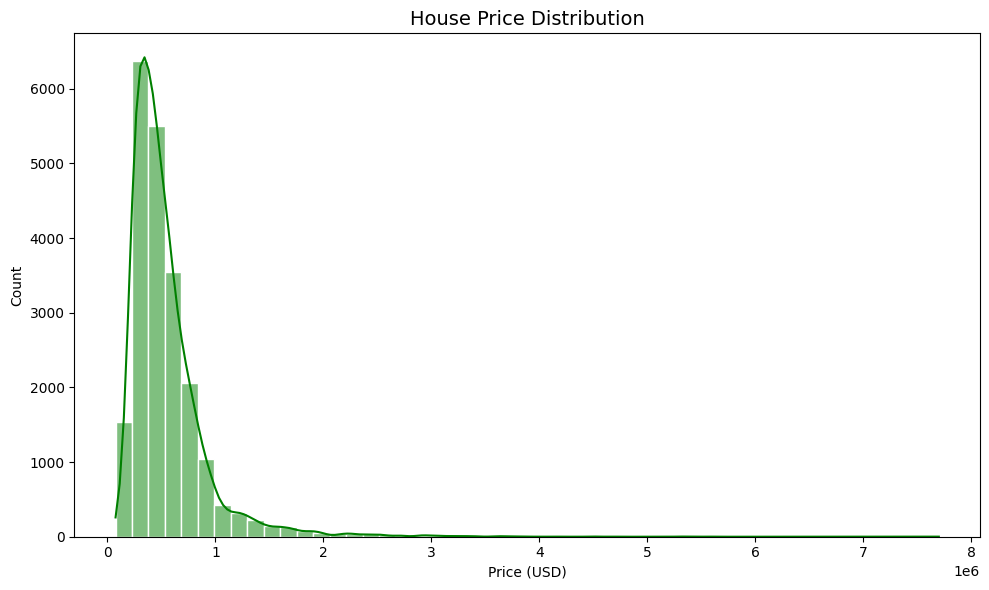

In [8]:
# Visualise price distribution
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, color='green', edgecolor='white',kde=True)
plt.title('House Price Distribution', fontsize=14)
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()


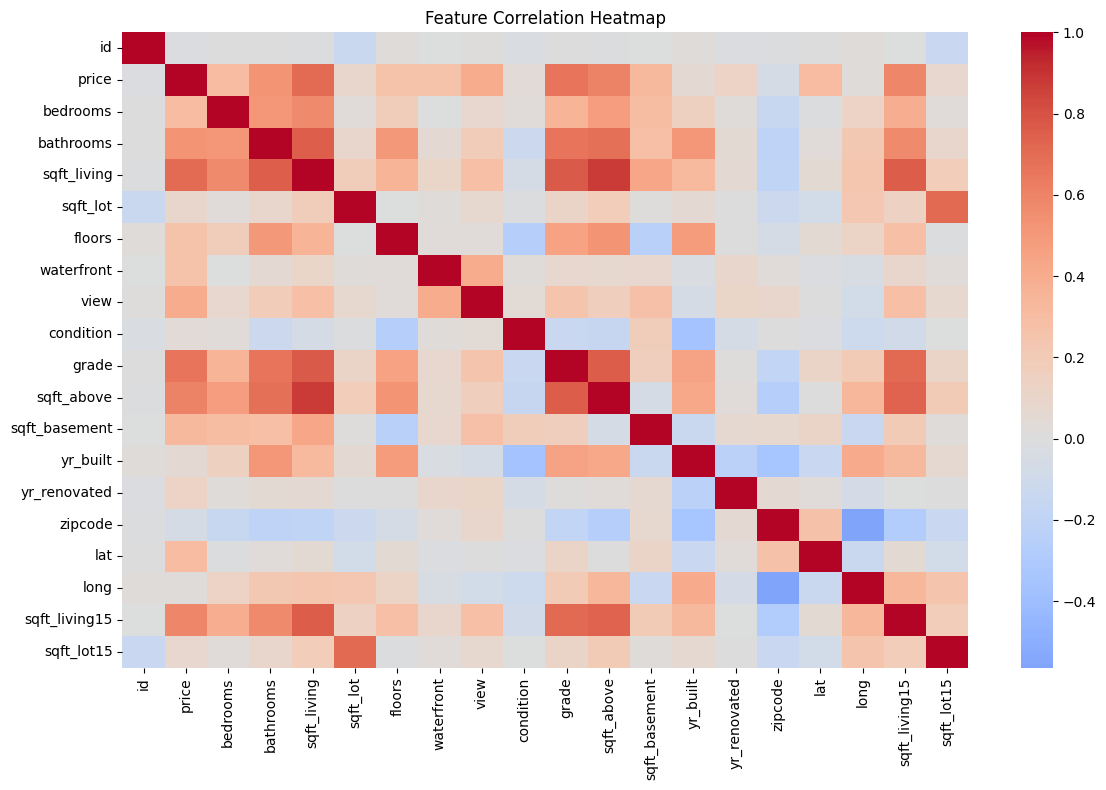

In [24]:
# Correlation heatmap
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


In [16]:
# Prepare features for model training
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
            'floors', 'waterfront', 'view', 'condition', 'grade',
            'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
            'lat', 'long', 'sqft_living15', 'sqft_lot15']

X = df[features]
y = df['price']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 17290
Testing samples: 4323


In [17]:
# Train Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [18]:
# Evaluate the model
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))

print("=" * 40)
print("MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"R² Score:  {r2:.4f}  ({r2*100:.1f}% accuracy)")
print(f"RMSE:      ${rmse:,.0f}")
print(f"MAE:       ${mae:,.0f}")


MODEL PERFORMANCE RESULTS
R² Score:  0.8487  (84.9% accuracy)
RMSE:      $151,246
MAE:       $73,606


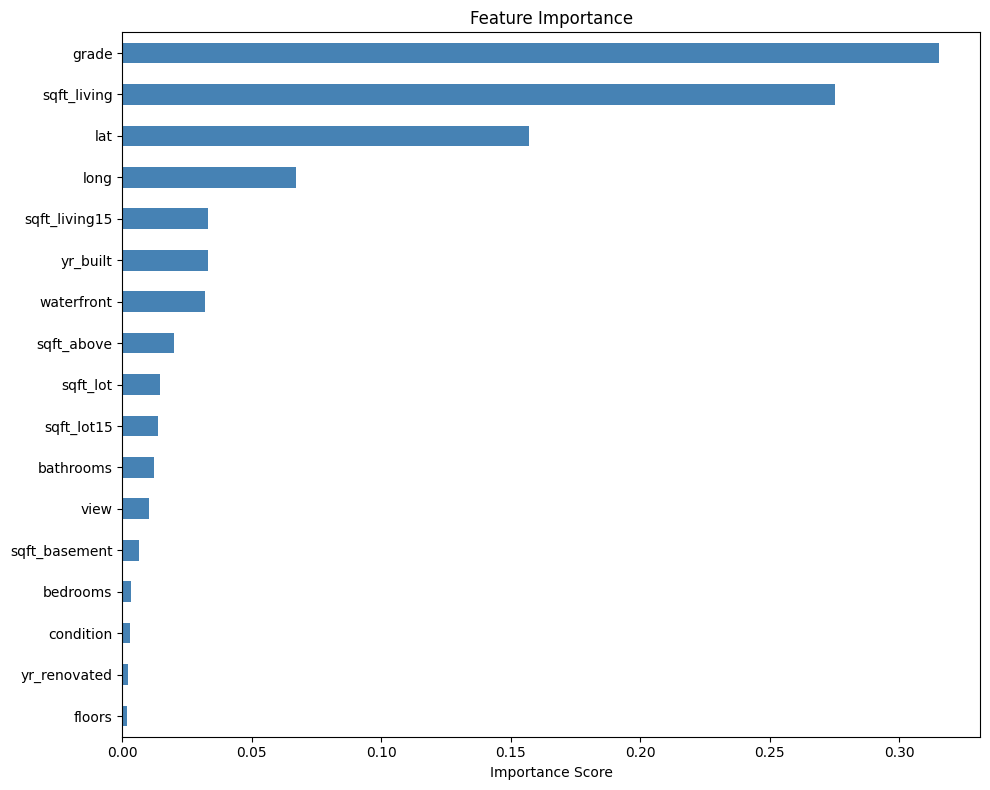

In [23]:
# Feature importance chart
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [28]:
import joblib

joblib.dump(model, "house_price_model.pkl", compress=3)

['house_price_model.pkl']

In [29]:
import os
print(os.path.getsize("house_price_model.pkl")/(1024*1024), "MB")

24.00450038909912 MB


In [31]:
import joblib
from google.colab import files

# Save compressed model
joblib.dump(model, 'house_price_model.pkl', compress=3)

# Download files
files.download('house_price_model.pkl')
files.download('price_distribution.png')
files.download('correlation_heatmap.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>